for each trail: how does temp change throughout the year, which months have the highest chance of rain, how does cloud cover
change throughout the day in peak szn

In [46]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# let the notebook import from ../src (notebooks live one folder below the project root)
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.trails import TRAILS
from src.fetch import fetch_history

DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR.mkdir(exist_ok=True)


In [47]:
all_dfs = []

for trail in TRAILS:
    csv_path = DATA_DIR / f"{trail['id']}.csv"

    if csv_path.exists():
        df = pd.read_csv(csv_path, parse_dates=["time"])
    else:
        df = fetch_history(trail["lat"], trail["lon"])
        df.to_csv(csv_path, index=False)

    df["trail"] = trail["name"]
    all_dfs.append(df)

combined = pd.concat(all_dfs)
print(combined.shape)

(482160, 7)


In [48]:

combined.groupby("trail").size()  

trail
Hornstrandir         96432
kalalau trail        96432
reinebringen         96432
savage river loop    96432
tianzi mountain      96432
dtype: int64

In [49]:

combined.isna().groupby(combined["trail"]).sum()    # missing values per trail


,time,temperature_2m,precipitation,cloud_cover,wind_speed_10m,relative_humidity_2m,trail
trail,,,,,,,
Hornstrandir,0,0,0,0,0,0,0
kalalau trail,0,0,0,0,0,0,0
reinebringen,0,0,0,0,0,0,0
savage river loop,0,0,0,0,0,0,0
tianzi mountain,0,0,0,0,0,0,0


In [50]:

combined["month"] = combined["time"].dt.month
combined["hour"] = combined["time"].dt.hour
combined["is_raining"] = combined["precipitation"] > 0.1

# is "> 0" the right rain threshold? Tiny drizzle amounts might count as rain here.
# look at df["precipitation"].describe() and decide- maybe 0.1 mm is better.


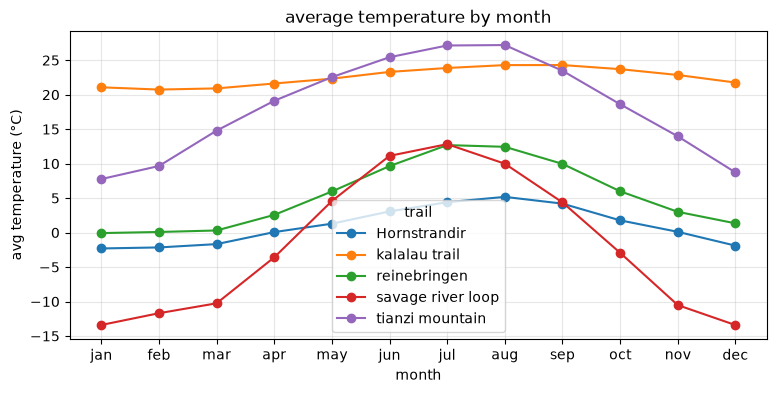

In [51]:

monthly_temp = combined.groupby(["trail", "month"])["temperature_2m"].mean().unstack("trail")

fig, ax = plt.subplots(figsize=(9, 4))
monthly_temp.plot(ax=ax, marker="o")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"])
ax.set_xlabel("month")
ax.set_ylabel("avg temperature (°C)")
ax.set_title("average temperature by month")
ax.grid(alpha=0.3)
plt.show()


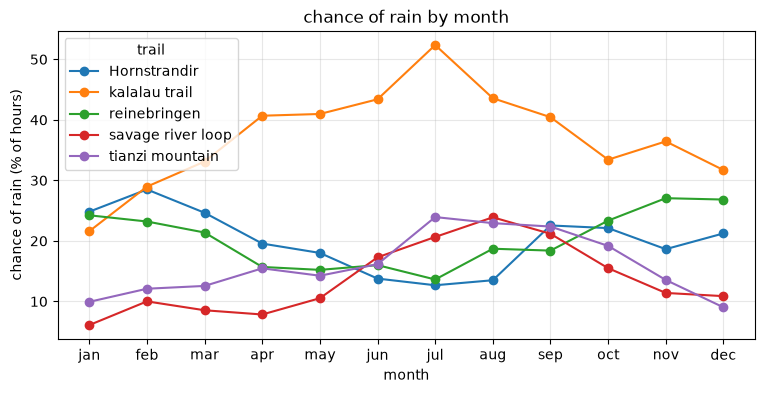

In [55]:
rain_chance = combined.groupby(["trail", "month"])["is_raining"].mean().unstack("trail") * 100

fig, ax = plt.subplots(figsize=(9, 4))
rain_chance.plot(ax=ax, marker="o")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"])
ax.set_xlabel("month")
ax.set_ylabel("chance of rain (% of hours)")
ax.set_title("chance of rain by month")
ax.grid(alpha=0.3)
plt.show()

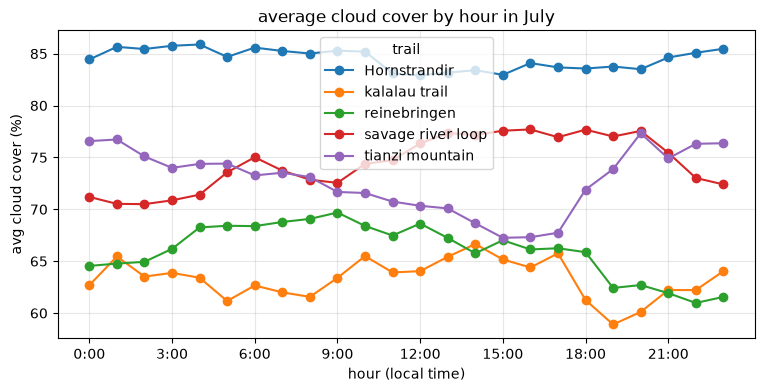

In [52]:
import calendar

MONTH = 7

summer = combined[combined["month"] == MONTH]
hourly_cloud = summer.groupby(["trail", "hour"])["cloud_cover"].mean().unstack("trail")

fig, ax = plt.subplots(figsize=(9, 4))
hourly_cloud.plot(ax=ax, marker="o")
ax.set_xticks(range(0, 24, 3))
ax.set_xticklabels([f"{h}:00" for h in range(0, 24, 3)])
ax.set_xlabel("hour (local time)")
ax.set_ylabel("avg cloud cover (%)")
ax.set_title(f"average cloud cover by hour in {calendar.month_name[MONTH]}")
ax.grid(alpha=0.3)
plt.show()
